This notebook solves for the acoustic phonon dispersion in Gallium Nitride, as discussed in Chapter 1 of Sam Bader's PhD Thesis

In [1]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

Define problem space
===

In [2]:
# Import symbolic computation
from sympy import *
init_printing()

In [3]:
# Formally define coordinates vector r and time t
r=ImmutableMatrix(['x','y','z'])
t=symbols("t")

# Formally define displacement vector u (as functions of spatial coordinates)
u=ImmutableMatrix([Function(ui)(*[r[j] for j in range(3)]+[t]) for ui in ['u_x','u_y','u_z']])

# Convenience dictionary of substitutions to print shorter formulas
printdict = {ui:uprinti for ui,uprinti in zip(u,symbols('u_x u_y u_z'))}

Define conventional stress and strain six-tuples
===

The stress tuple and resultant tensor


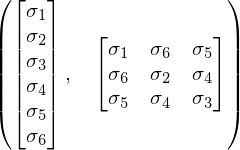

In [4]:
# Given a six-tuple describing stress, rearrange to tensor
def stress_tuple_to_tensor(v6):
    return ImmutableMatrix([[v6[1-1],v6[6-1],v6[5-1]],
                      [v6[6-1],v6[2-1],v6[4-1]],
                      [v6[5-1],v6[4-1],v6[3-1]]])
stress_tuple=ImmutableMatrix(["sigma"+str(x) for x in range(1,6+1)])
print("The stress tuple and resultant tensor")
(stress_tuple,stress_tuple_to_tensor(stress_tuple))

The strain tensor and resultant tuple


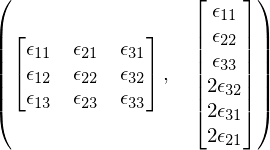

In [5]:
# Given a tensor describing strain, extract a six-tuple,
# including the conventional factors of two for elements 4,5,6
def strain_tensor_to_tuple(t33):
    return ImmutableMatrix([t33[0,0],t33[1,1],t33[2,2],t33[1,2]*2,t33[0,2]*2,t33[0,1]*2])
strain_tensor=ImmutableMatrix([["epsilon_"+str(i)+str(j) for i in range(1,3+1)] for j in range(1,3+1)])
print("The strain tensor and resultant tuple")
(strain_tensor,strain_tensor_to_tuple(strain_tensor))

Define some vector calculus operations
===

In [6]:
# Symmetric vector gradient, ie eps_ij=(du_i/dx_j+du_j/dx_i)/2
def symgrad(field,position):
    grad=ImmutableMatrix([[field[i].diff(position[j]) for j in range(3)] for i in range(3)])
    return (grad+grad.T)/2
print("A field u, and its symmetric gradient")
(u.subs(printdict),symgrad(u,r).subs(printdict))

A field u, and its symmetric gradient


A generic tensor and its divergence


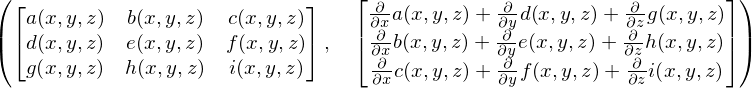

In [7]:
# Tensor divergence

def div(field,position):
    return ImmutableMatrix([sum([diff(field[i,j],position[i],evaluate=True) for i in range(3)]) for j in range(3)])

tensor=ImmutableMatrix([["a(x,y,z)", "b(x,y,z)","c(x,y,z)"],
                        ["d(x,y,z)","e(x,y,z)","f(x,y,z)"],
                        ["g(x,y,z)","h(x,y,z)","i(x,y,z)"]])
print("A generic tensor and its divergence")
(tensor,div(tensor,r))

Two vectors and their dot product


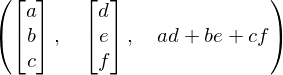

In [8]:
# Dot product of two vectors

def dot(field1,field2):
    return sum(field1[i]*field2[i] for i in range(3))

va=ImmutableMatrix(["a","b","c"])
vb=ImmutableMatrix(["d","e","f"])
print("Two vectors and their dot product")
(va,vb,dot(va,vb))

Apply Hooke's Law
===

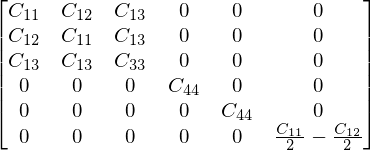

In [9]:
# Stiffness tensor for hexagonal crystal

C11,C12=symbols("C11 C12")
C=ImmutableMatrix([
        ["C11","C12","C13",0,0,0],
        ["C12","C11","C13",0,0,0],
        ["C13","C13","C33",0,0,0],
        [0,0,0,"C44",0,0],
        [0,0,0,0,"C44",0],
        [0,0,0,0,0,(C11-C12)/2]])
C

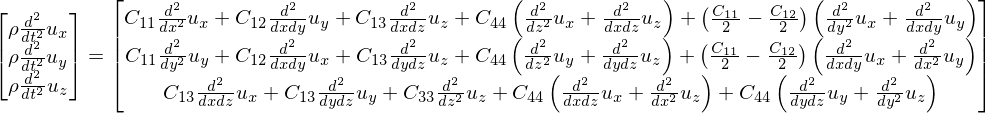

In [10]:
# This is just Newton's/Hooke's law, with conversion between stress/strain formats
# rho * d^2u/dt^2 = div * (C * symgrad(u))
rho,omega=symbols("rho omega")
diffeq=Eq(rho*u.diff(t,t),div(stress_tuple_to_tensor(C*strain_tensor_to_tuple(symgrad(u,r))),r))
diffeq.subs(printdict)

Insert an ansatz
===

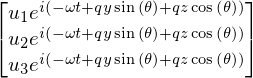

In [11]:
# q vector in y-z plane with polar angle theta, magnitude q
theta,q =symbols("theta, q")
qv=Matrix([0,q*sin(theta),q*cos(theta)])

# vector ansatz
u_ans=Matrix(["u1","u2","u3"])*exp(I*(dot(qv,r)-omega*t))
u_ans

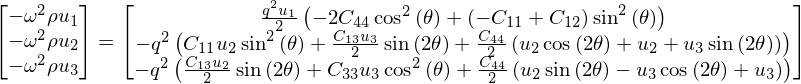

In [12]:
# Plug it in, evaluate derivatives, simplify, and divide out the exponential
with_ansatz=simplify(
    diffeq.subs(
            {"u_"+["x","y","z"][xi]+"(x,y,z,t)":u_ansi
                 for xi,u_ansi in enumerate(u_ans)})\
        .doit())
with_ansatz=Eq(*[a/exp(I*(dot(qv,r)-omega*t)) for a in with_ansatz.args])
with_ansatz

Examine solutions along specific angles
===

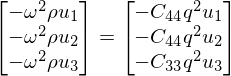

In [13]:
# wavevector along z-axis
with_ansatz.subs(theta,0)

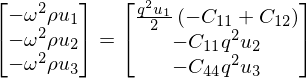

In [14]:
# wavevector along y-axis
with_ansatz.subs(theta,pi/2)

Get actual values
===

In [15]:
import pynitride as pn
from pynitride.crystruct.direct import density
GaN=pn.Material("GaN")
stiffness=GaN['stiffness']
rho=density(GaN)


print("v_s={:.3g} cm/s TA along c-axis".format(pn.to_unit(sqrt(stiffness['C44']/rho),"cm/s")))
print("v_s={:.3g} cm/s TA along c-axis".format(pn.to_unit(sqrt(stiffness['C44']/rho),"cm/s")))
print("v_s={:.3g} cm/s LA along c-axis".format(pn.to_unit(sqrt(stiffness['C33']/rho),"cm/s")))
print()
print("v_s={:.3g} cm/s TA_basal in plane".format(pn.to_unit(sqrt((stiffness['C11']-stiffness['C12'])/rho),"cm/s")))
print("v_s={:.3g} cm/s LA       in plane".format(pn.to_unit(sqrt(stiffness['C11']/rho),"cm/s")))
print("v_s={:.3g} cm/s TA_axial in plane".format(pn.to_unit(sqrt(stiffness['C44']/rho),"cm/s")))

v_s=4.17e+5 cm/s TA along c-axis
v_s=4.17e+5 cm/s TA along c-axis
v_s=8.12e+5 cm/s LA along c-axis

v_s=6.37e+5 cm/s TA_basal in plane
v_s=8.04e+5 cm/s LA       in plane
v_s=4.17e+5 cm/s TA_axial in plane
